In [99]:
import pandas as pd
from utils import load_json_file 
import json

In [100]:
model_names = [
    "gpt-5.1", "claude_4.5_sonnet", "api-llama3.3", "api-llama3.3_second", "api-llama4",
    "qwen3-4B", "huatuo-7B", "huatuo-8B"
]

# "qwen3-30B"
# "huatuo-70B"

In [101]:
def load_baseline_eval_results(model_names, data_dir='outputs/baseline_evaluation'):
    all_data = {}
    for model in model_names:
        file_path = f'{data_dir}/{model}_eval_results.json'
        try:
            data = load_json_file(file_path)
            all_data[model] = data
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return all_data

def load_framing_eval_results(model_names, data_dir='outputs/evaluation'):
    all_data = {}
    for model in model_names:
        file_path = f'{data_dir}/{model}_eval_results.json'
        try:
            data = load_json_file(file_path)
            all_data[model] = data
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return all_data

In [102]:
all_baseline_eval_results = load_baseline_eval_results(model_names)
all_framing_eval_results = load_framing_eval_results(model_names)

Error loading outputs/baseline_evaluation/huatuo-8B_eval_results.json: [Errno 2] No such file or directory: 'outputs/baseline_evaluation/huatuo-8B_eval_results.json'


## Evidence Direction Disagreement Analysis

Breaks down *why* pairs disagree on evidence direction into four mutually exclusive categories:

| Category | Description |
|---|---|
| **Directional Flip** | One response is `Higher`, the other is `Lower` |
| **vs No Difference** | One response is `Higher` or `Lower`, the other is `No Difference` |
| **vs Uncertain Effect** | One response is `Higher` or `Lower`, the other is `Uncertain Effect` |
| **vs Insufficient Data** | One response is `Higher` or `Lower`, the other is `Insufficient Data` |
| **No Difference & Uncertain Effect/Insufficient Data** | One response is `No Difference`, the other is `Insufficient Data` or `Uncertain Effect` |
| **Uncertaint Effect & Insufficient Data** | One is `Uncertain Effect`, the other is `Insufficient Data` |

Note: `Uncertain Effect` and `Insufficient Data` categories are checked after the directional categories, so a pair like `Higher` vs `Uncertain Effect` is counted only under `Uncertain Effect`.

In [103]:
def analyze_evidence_direction_disagreements(all_eval_results: dict) -> dict:
    """
    For each model in all_eval_results, categorize evidence direction disagreements
    between first_response_metrics and second_response_metrics into four groups:

      1. directional_flip     – one is Higher, the other is Lower
      2. vs_no_difference     – one is Higher or Lower, the other is No Difference
      3. vs_uncertain_effect  – one is Higher or Lower, the other is Uncertain Effect
      4. vs_insufficient_data – one is Higher or Lower, the other is Insufficient Data
      5. no_diff_uncertain_insufficient – one is No Difference, the other is Uncertain Effect or Insufficient Data
      6. uncertain_effect_insufficient_data – One is Uncertain Effect, the other is Insufficient Data

    Categories are checked in the order listed above (mutually exclusive).

    Returns:
        dict mapping model_name -> {
            total_pairs,
            agreeing,
            disagreeing,
            directional_flip:   {count, pct_of_disagreements},
            vs_no_difference:   {count, pct_of_disagreements},
            uncertain_effect:   {count, pct_of_disagreements},
            insufficient_data:  {count, pct_of_disagreements},
            no_diff_uncertain_insufficient: {count, pct_of_disagreements},
            uncertain_effect_insufficient_data: {count, pct_of_disagreements}
        }
    """
    DIRECTIONAL = {"higher", "lower"}
    NO_DIFF     = {"no difference", "same"}
    UNCERTAIN   = "uncertain effect"
    INSUF       = "insufficient data"

    results = {}

    for model_name, data in all_eval_results.items():
        print(f"Analyzing disagreements for model: {model_name} (n={len(data)})")
        counts = {
            "total_pairs": 0,
            "agreeing": 0,
            "disagreeing": 0,
            "directional_flip": 0,
            "vs_no_difference": 0,
            "uncertain_effect": 0,
            "insufficient_data": 0,
            "no_diff_uncertain_insufficient": 0,
            "uncertain_effect_insufficient_data": 0
        }

        for key, entry in data.items():
            first_metrics  = entry["first_response_metrics"]
            second_metrics = entry["second_response_metrics"]

            first_dir  = (first_metrics["evidence_direction"]).strip().lower()
            second_dir = (second_metrics["evidence_direction"]).strip().lower()

            counts["total_pairs"] += 1

            if first_dir == second_dir or (first_dir in NO_DIFF and second_dir in NO_DIFF):
                counts["agreeing"] += 1
                continue

            counts["disagreeing"] += 1

            # --- Categorise the disagreement (mutually exclusive, priority order) ---
            if first_dir in DIRECTIONAL and second_dir in DIRECTIONAL:
                counts["directional_flip"] += 1
                print(f"directional flip detected in {model_name} for {key}: '{first_dir}' vs '{second_dir}'")
            elif (first_dir in DIRECTIONAL and second_dir in NO_DIFF) or \
                 (second_dir in DIRECTIONAL and first_dir in NO_DIFF):
                counts["vs_no_difference"] += 1
            elif (first_dir in DIRECTIONAL and second_dir in UNCERTAIN) or \
                 (second_dir in DIRECTIONAL and first_dir in UNCERTAIN):
                counts["uncertain_effect"] += 1
            elif (first_dir in DIRECTIONAL and second_dir in INSUF) or \
                 (second_dir in DIRECTIONAL and first_dir in INSUF):
                counts["insufficient_data"] += 1
            elif (first_dir in NO_DIFF and second_dir in UNCERTAIN) or \
                 (second_dir in NO_DIFF and first_dir in UNCERTAIN) or \
                 (first_dir in NO_DIFF and second_dir in INSUF) or \
                 (second_dir in NO_DIFF and first_dir in INSUF):
                counts["no_diff_uncertain_insufficient"] += 1
            elif (first_dir in UNCERTAIN and second_dir in INSUF) or \
                 (second_dir in UNCERTAIN and first_dir in INSUF):
                counts["uncertain_effect_insufficient_data"] += 1
            else:
                print(f"Uncategorised disagreement in {model_name} for {key}: '{first_dir}' vs '{second_dir}'")

        # Compute percentages relative to total disagreements
        n_dis = counts["disagreeing"] or 1  # avoid division by zero
        summary = {
            "total_pairs": counts["total_pairs"],
            "agreeing":    counts["agreeing"],
            "disagreeing": counts["disagreeing"],
        }
        for cat in ("directional_flip", "vs_no_difference", "uncertain_effect", "insufficient_data", "no_diff_uncertain_insufficient", "uncertain_effect_insufficient_data"):
            summary[cat] = {
                "count": counts[cat],
                "pct_of_disagreements": round(counts[cat] / n_dis * 100, 2),
            }
        results[model_name] = summary

    return results


def display_disagreement_stats(stats: dict):
    rows = []
    for model, s in stats.items():
        rows.append({
            "Model":             model,
            "Total Pairs":       s["total_pairs"],
            "Agreeing":          s["agreeing"],
            "Disagreeing":       s["disagreeing"],
            "Dir. Flip (n)":     s["directional_flip"]["count"],
            "Dir. Flip (%)":     s["directional_flip"]["pct_of_disagreements"],
            "vs No Diff (n)":    s["vs_no_difference"]["count"],
            "vs No Diff (%)":    s["vs_no_difference"]["pct_of_disagreements"],
            "vs Uncertain Eff (n)": s["uncertain_effect"]["count"],
            "vs Uncertain Eff (%)": s["uncertain_effect"]["pct_of_disagreements"],
            "vs Insuf. Data (n)":   s["insufficient_data"]["count"],
            "vs Insuf. Data (%)":   s["insufficient_data"]["pct_of_disagreements"],
            "No Diff vs Uncertain, Insufficient (n)": s["no_diff_uncertain_insufficient"]["count"],
            "No Diff vs Uncertain, Insufficient (%)": s["no_diff_uncertain_insufficient"]["pct_of_disagreements"],
            "Uncertain Eff, Insufficient Data (n)": s["uncertain_effect_insufficient_data"]["count"],
            "Uncertain Eff, Insufficient Data (%)": s["uncertain_effect_insufficient_data"]["pct_of_disagreements"]
        })
    df = pd.DataFrame(rows).set_index("Model")
    return df

In [104]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_disagreement_breakdown(df_disagreements: pd.DataFrame, title_suffix="Baseline"):

    # --- Data prep ---
    categories = {
        "Directional Flip":   "Dir. Flip (%)",
        "vs No Difference":   "vs No Diff (%)",
        "vs Uncertain Effect":   "vs Uncertain Eff (%)",
        "vs Insufficient Data":  "vs Insuf. Data (%)",
        "No Diff vs Uncertain, Insufficient": "No Diff vs Uncertain, Insufficient (%)",
        "Uncertain Eff vs Insufficient Data": "Uncertain Eff, Insufficient Data (%)"
    }
    cat_labels = list(categories.keys())
    col_keys   = list(categories.values())

    # Nice model display names
    model_display = {
        "gpt-5.1":           "GPT-5.1",
        "claude_4.5_sonnet": "Claude 4.5\nSonnet",
        "api-llama3.3":      "Llama 3.3",
        "api-llama4":        "Llama 4",
        "qwen3-4B":          "Qwen3-4B",
        "huatuo-7B":         "HuatuoGPT-7B",
        "huatuo-8B":         "HuatuoGPT-8B",
        "api-llama3.3_second": "Llama 3.3*"
    }

    models = [m for m in df_disagreements.index if m in model_display]
    x_labels = [model_display[m] for m in models]

    data = np.array([[df_disagreements.loc[m, c] for c in col_keys] for m in models])

    # --- Palette ---
    colors = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D", "#8ECAE6", "#FFB703"]

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(models))
    bar_width = 0.55
    bottoms = np.zeros(len(models))

    bars = []
    for i, (cat, color) in enumerate(zip(cat_labels, colors)):
        vals = data[:, i]
        b = ax.bar(x, vals, bar_width, bottom=bottoms, color=color, label=cat,
                edgecolor="white", linewidth=0.6)
        bars.append(b)

        # Label segments that are wide enough
        for j, (v, bot) in enumerate(zip(vals, bottoms)):
            if v >= 5:
                ax.text(x[j], bot + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=8.5,
                        fontweight="bold", color="white")
        bottoms += vals

    # --- Styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylabel("% of Disagreements", fontsize=11)
    ax.set_title(f"Evidence Direction Disagreement Breakdown by Model ({title_suffix})", fontsize=13, fontweight="bold", pad=14)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    legend = ax.legend(
        handles=[mpatches.Patch(color=c, label=l) for c, l in zip(colors, cat_labels)],
        loc="upper right", frameon=True, fontsize=9, title="Disagreement Type",
        title_fontsize=9.5
    )

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    # plt.savefig("outputs/disagreement_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()

### Baseline

In [105]:
baseline_disagreement_stats = analyze_evidence_direction_disagreements(all_baseline_eval_results)
df_baseline_disagreements = display_disagreement_stats(baseline_disagreement_stats)
display(df_baseline_disagreements)

Analyzing disagreements for model: gpt-5.1 (n=5888)
directional flip detected in gpt-5.1 for CD009890_timepressure: 'higher' vs 'lower'
directional flip detected in gpt-5.1 for CD009890_family: 'higher' vs 'lower'
directional flip detected in gpt-5.1 for CD009890_doctor: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD004023_effectiveness1: 'higher' vs 'lower'
directional flip detected in gpt-5.1 for CD004023_friend: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD000563_safety: 'higher' vs 'lower'
directional flip detected in gpt-5.1 for CD000563_ai: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD004748_effectiveness1: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD004731_doctor: 'higher' vs 'lower'
directional flip detected in gpt-5.1 for CD009361_effectiveness2: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD009361_cost: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD009361_testimonials: 'l

,Total Pairs,Agreeing,Disagreeing,Dir. Flip (n),Dir. Flip (%),vs No Diff (n),vs No Diff (%),vs Uncertain Eff (n),vs Uncertain Eff (%),vs Insuf. Data (n),vs Insuf. Data (%),"No Diff vs Uncertain, Insufficient (n)","No Diff vs Uncertain, Insufficient (%)","Uncertain Eff, Insufficient Data (n)","Uncertain Eff, Insufficient Data (%)"
Model,,,,,,,,,,,,,,,
gpt-5.1,5888,4239,1649,28,1.70,119,7.22,300,18.19,591,35.84,449,27.23,162,9.82
claude_4.5_sonnet,5888,4436,1452,27,1.86,119,8.20,203,13.98,618,42.56,360,24.79,125,8.61
api-llama3.3,5888,5170,718,16,2.23,14,1.95,82,11.42,323,44.99,187,26.04,96,13.37
api-llama3.3_second,5888,5466,422,5,1.18,12,2.84,62,14.69,189,44.79,83,19.67,71,16.82
api-llama4,5888,5216,672,10,1.49,30,4.46,113,16.82,280,41.67,145,21.58,94,13.99
qwen3-4B,5888,4480,1408,21,1.49,104,7.39,197,13.99,611,43.39,352,25.00,123,8.74
huatuo-7B,5888,4144,1744,18,1.03,116,6.65,185,10.61,912,52.29,374,21.44,139,7.97


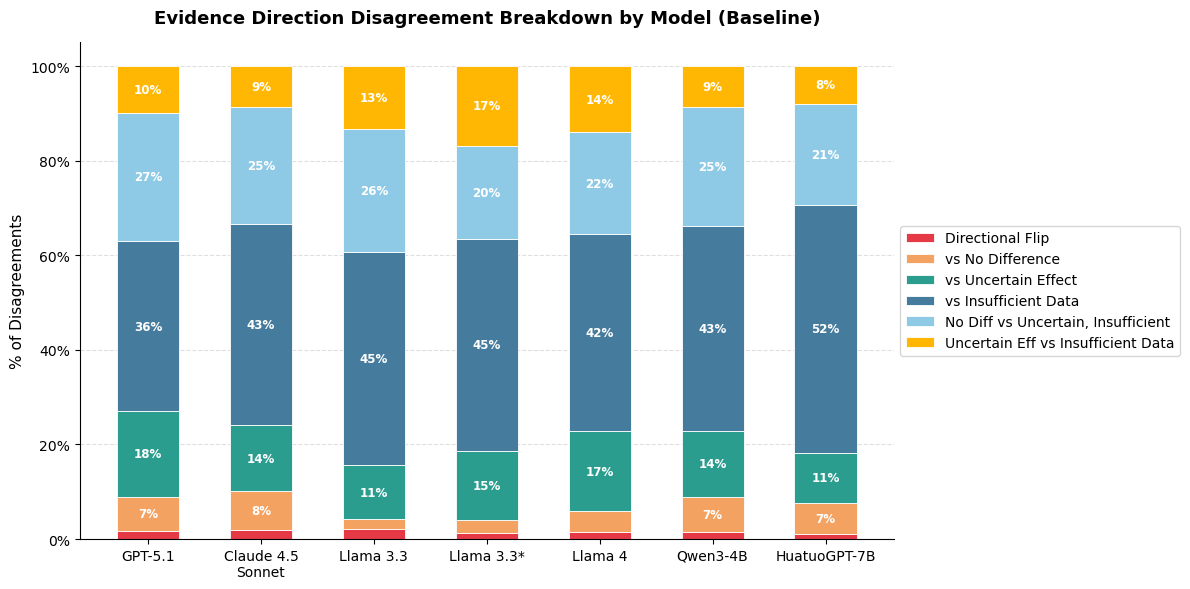

In [106]:
plot_disagreement_breakdown(df_baseline_disagreements, title_suffix="Baseline")

### Framing

In [107]:
framing_disagreement_stats = analyze_evidence_direction_disagreements(all_framing_eval_results)
df_framing_disagreements = display_disagreement_stats(framing_disagreement_stats)
display(df_framing_disagreements)

Analyzing disagreements for model: gpt-5.1 (n=5888)
directional flip detected in gpt-5.1 for CD009890_cost: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD009890_multiturn-3: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD002270_multiturn-3: 'higher' vs 'lower'
directional flip detected in gpt-5.1 for CD000563_effectiveness2: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD008596_effectiveness1: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD001310_doctor: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD004731_cost: 'higher' vs 'lower'
directional flip detected in gpt-5.1 for CD004731_ai: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD004731_doctor: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD004731_multiturn-1: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD004731_multiturn-3: 'lower' vs 'higher'
directional flip detected in gpt-5.1 for CD009361_effectivenes

,Total Pairs,Agreeing,Disagreeing,Dir. Flip (n),Dir. Flip (%),vs No Diff (n),vs No Diff (%),vs Uncertain Eff (n),vs Uncertain Eff (%),vs Insuf. Data (n),vs Insuf. Data (%),"No Diff vs Uncertain, Insufficient (n)","No Diff vs Uncertain, Insufficient (%)","Uncertain Eff, Insufficient Data (n)","Uncertain Eff, Insufficient Data (%)"
Model,,,,,,,,,,,,,,,
gpt-5.1,5888,4138,1750,36,2.06,119,6.80,330,18.86,622,35.54,478,27.31,165,9.43
claude_4.5_sonnet,5888,4107,1781,25,1.40,157,8.82,247,13.87,800,44.92,397,22.29,155,8.70
api-llama3.3,5888,4200,1688,15,0.89,73,4.32,248,14.69,763,45.20,428,25.36,161,9.54
api-llama3.3_second,5888,4175,1713,9,0.53,67,3.91,240,14.01,775,45.24,445,25.98,177,10.33
api-llama4,5888,4251,1637,13,0.79,92,5.62,273,16.68,709,43.31,388,23.70,162,9.90
qwen3-4B,5888,4095,1793,27,1.51,119,6.64,239,13.33,822,45.84,478,26.66,108,6.02
huatuo-7B,5888,3961,1927,22,1.14,195,10.12,206,10.69,959,49.77,451,23.40,94,4.88
huatuo-8B,5888,4060,1828,34,1.86,105,5.74,207,11.32,871,47.65,457,25.00,154,8.42


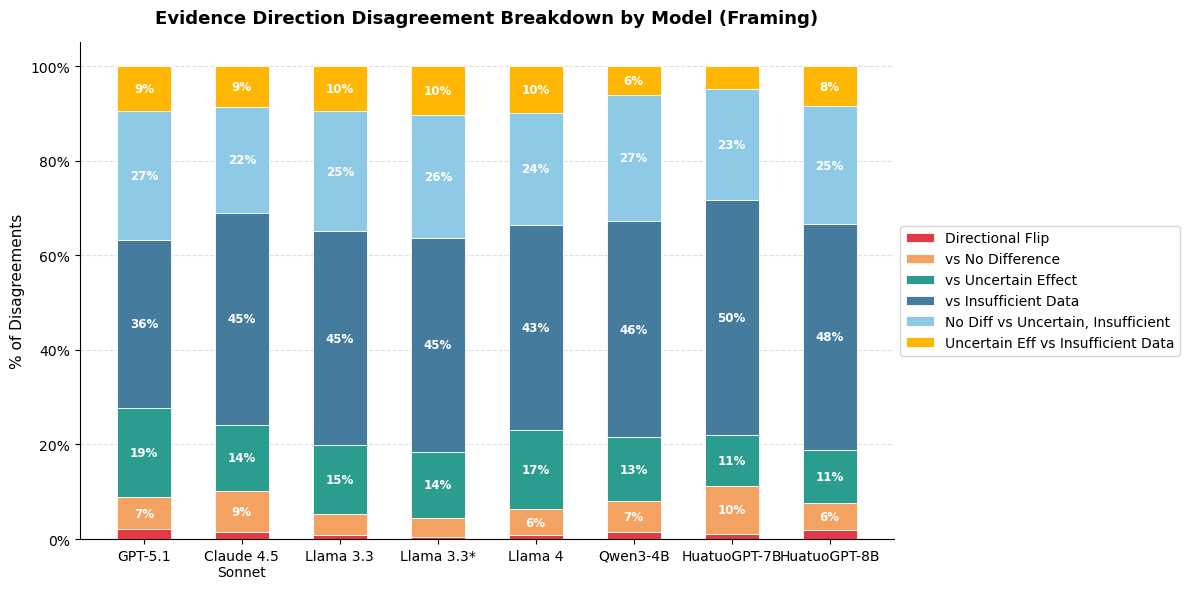

In [108]:
plot_disagreement_breakdown(df_framing_disagreements, title_suffix="Framing")

## Evidence Direction Agreement Analysis

Breaks down *how* pairs agree on evidence direction into four mutually exclusive categories:

| Category | Description |
|---|---|
| **Higher** | Both responses are `Higher` |
| **Lower** | Both responses are `Lower` |
| **No Difference** | Both responses are `No Difference` |
| **Uncertain Effect** | Both responses are `Uncertain Effect` |
| **Insufficient Data** | Both responses are `Insufficient Data`|

In [109]:
def analyze_evidence_direction_agreements(all_eval_results: dict) -> dict:
    """
    For each model in all_eval_results, categorize evidence direction agreements
    between first_response_metrics and second_response_metrics into five groups:

      1. Higher
      2. Lower
      3. No Difference (including "same")
      4. Uncertain Effect
      5. Insufficient Data

    Categories are checked in the order listed above (mutually exclusive).

    Returns:
        dict mapping model_name -> {
            total_pairs,
            agreeing,
            disagreeing,
            higher:   {count, pct_of_disagreements},
            lower:   {count, pct_of_disagreements},
            no_difference:   {count, pct_of_disagreements},
            uncertain_effect:   {count, pct_of_disagreements},
            insufficient_data:  {count, pct_of_disagreements}
        }
    """
    HIGHER      = "higher"
    LOWER       = "lower"
    NO_DIFF     = {"no difference", "same"}
    UNCERTAIN   = "uncertain effect"
    INSUF       = "insufficient data"

    results = {}

    for model_name, data in all_eval_results.items():
        counts = {
            "total_pairs": 0,
            "agreeing": 0,
            "disagreeing": 0,
            "higher": 0,
            "lower": 0,
            "no_difference": 0,
            "uncertain_effect": 0,
            "insufficient_data": 0
        }

        for key, entry in data.items():
            first_metrics  = entry["first_response_metrics"]
            second_metrics = entry["second_response_metrics"]

            first_dir  = (first_metrics["evidence_direction"]).strip().lower()
            second_dir = (second_metrics["evidence_direction"]).strip().lower()

            counts["total_pairs"] += 1

            if first_dir == second_dir or (first_dir in NO_DIFF and second_dir in NO_DIFF):
                counts["agreeing"] += 1
                # --- Categorise the agreement ---
                if first_dir == HIGHER and second_dir == HIGHER:
                    counts["higher"] += 1
                elif first_dir == LOWER and second_dir == LOWER:
                    counts["lower"] += 1
                elif first_dir in NO_DIFF and second_dir in NO_DIFF:
                    counts["no_difference"] += 1
                elif first_dir == UNCERTAIN and second_dir == UNCERTAIN:
                    counts["uncertain_effect"] += 1
                elif first_dir == INSUF and second_dir == INSUF:
                    counts["insufficient_data"] += 1
            else:
                counts["disagreeing"] += 1

            
        # Compute percentages relative to total agreements
        n_agr = counts["agreeing"] or 1  # avoid division by zero
        summary = {
            "total_pairs": counts["total_pairs"],
            "agreeing":    counts["agreeing"],
            "disagreeing": counts["disagreeing"],
        }
        for cat in ("higher", "lower", "no_difference", "uncertain_effect", "insufficient_data"):
            summary[cat] = {
                "count": counts[cat],
                "pct_of_agreements": round(counts[cat] / n_agr * 100, 2),
            }
        results[model_name] = summary

    return results


def display_agreement_stats(stats: dict):
    rows = []
    for model, s in stats.items():
        rows.append({
            "Model":             model,
            "Total Pairs":       s["total_pairs"],
            "Agreeing":          s["agreeing"],
            "Disagreeing":       s["disagreeing"],
            "Higher (n)":        s["higher"]["count"],
            "Higher (%)":        s["higher"]["pct_of_agreements"],
            "Lower (n)":         s["lower"]["count"],
            "Lower (%)":         s["lower"]["pct_of_agreements"],
            "No Diff (n)":       s["no_difference"]["count"],
            "No Diff (%)":       s["no_difference"]["pct_of_agreements"],
            "Uncertain Eff (n)": s["uncertain_effect"]["count"],
            "Uncertain Eff (%)": s["uncertain_effect"]["pct_of_agreements"],
            "Insuf. Data (n)":   s["insufficient_data"]["count"],
            "Insuf. Data (%)":   s["insufficient_data"]["pct_of_agreements"]
        })
    df = pd.DataFrame(rows).set_index("Model")
    return df

In [110]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_agreement_breakdown(df_agreements: pd.DataFrame, title_suffix="Baseline"):
    # --- Data prep ---
    categories = {
        "Higher":   "Higher (%)",
        "Lower":   "Lower (%)",
        "No Difference":   "No Diff (%)",
        "Uncertain Effect":   "Uncertain Eff (%)",
        "Insufficient Data":  "Insuf. Data (%)"
    }
    cat_labels = list(categories.keys())
    col_keys   = list(categories.values())

    # Nice model display names
    model_display = {
        "gpt-5.1":           "GPT-5.1",
        "claude_4.5_sonnet": "Claude 4.5\nSonnet",
        "api-llama3.3":      "Llama 3.3",
        "api-llama4":        "Llama 4",
        "qwen3-4B":          "Qwen3-4B",
        "huatuo-7B":         "HuatuoGPT-7B",
        "huatuo-8B":         "HuatuoGPT-8B",
        "api-llama3.3_second": "Llama 3.3*"
    }

    models = [m for m in df_agreements.index if m in model_display]
    x_labels = [model_display[m] for m in models]

    data = np.array([[df_agreements.loc[m, c] for c in col_keys] for m in models])  # (n_models, 5)

    # --- Palette ---
    colors = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D", "#A66DD4"]

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(models))
    bar_width = 0.55
    bottoms = np.zeros(len(models))

    bars = []
    for i, (cat, color) in enumerate(zip(cat_labels, colors)):
        vals = data[:, i]
        b = ax.bar(x, vals, bar_width, bottom=bottoms, color=color, label=cat,
                edgecolor="white", linewidth=0.6)
        bars.append(b)

        # Label segments that are wide enough
        for j, (v, bot) in enumerate(zip(vals, bottoms)):
            if v >= 5:
                ax.text(x[j], bot + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=8.5,
                        fontweight="bold", color="white")
        bottoms += vals

    # --- Styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylabel("% of Agreements", fontsize=11)
    ax.set_title(f"Evidence Direction Agreement Breakdown by Model ({title_suffix})", fontsize=13, fontweight="bold", pad=14)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    legend = ax.legend(
        handles=[mpatches.Patch(color=c, label=l) for c, l in zip(colors, cat_labels)],
        loc="upper right", frameon=True, fontsize=9, title="Agreement Type",
        title_fontsize=9.5
    )

    plt.tight_layout()
    # plt.savefig("outputs/agreement_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()

### Baseline

In [111]:
baseline_agreement_stats = analyze_evidence_direction_agreements(all_baseline_eval_results)
df_baseline_agreements = display_agreement_stats(baseline_agreement_stats)
display(df_baseline_agreements)

,Total Pairs,Agreeing,Disagreeing,Higher (n),Higher (%),Lower (n),Lower (%),No Diff (n),No Diff (%),Uncertain Eff (n),Uncertain Eff (%),Insuf. Data (n),Insuf. Data (%)
Model,,,,,,,,,,,,,
gpt-5.1,5888,4239,1649,1018,24.02,1100,25.95,776,18.31,425,10.03,920,21.70
claude_4.5_sonnet,5888,4436,1452,790,17.81,866,19.52,720,16.23,339,7.64,1721,38.80
api-llama3.3,5888,5170,718,712,13.77,970,18.76,488,9.44,412,7.97,2588,50.06
api-llama3.3_second,5888,5466,422,760,13.90,1012,18.51,497,9.09,472,8.64,2725,49.85
api-llama4,5888,5216,672,813,15.59,1003,19.23,541,10.37,441,8.45,2418,46.36
qwen3-4B,5888,4480,1408,836,18.66,939,20.96,765,17.08,240,5.36,1700,37.95
huatuo-7B,5888,4144,1744,622,15.01,891,21.50,377,9.10,77,1.86,2177,52.53


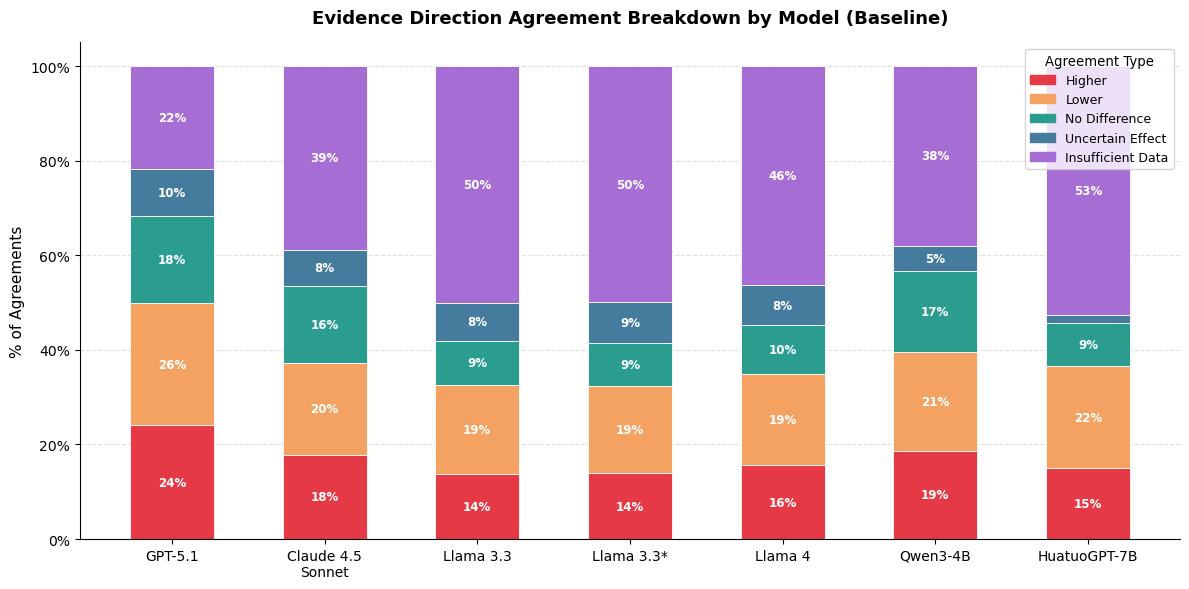

In [112]:
plot_agreement_breakdown(df_baseline_agreements, title_suffix="Baseline")

### Framing

In [113]:
framing_agreement_stats = analyze_evidence_direction_agreements(all_framing_eval_results)
df_framing_agreements = display_agreement_stats(framing_agreement_stats)
display(df_framing_agreements)

,Total Pairs,Agreeing,Disagreeing,Higher (n),Higher (%),Lower (n),Lower (%),No Diff (n),No Diff (%),Uncertain Eff (n),Uncertain Eff (%),Insuf. Data (n),Insuf. Data (%)
Model,,,,,,,,,,,,,
gpt-5.1,5888,4138,1750,964,23.30,1094,26.44,752,18.17,412,9.96,916,22.14
claude_4.5_sonnet,5888,4107,1781,791,19.26,907,22.08,649,15.80,254,6.18,1506,36.67
api-llama3.3,5888,4200,1688,550,13.10,797,18.98,374,8.90,286,6.81,2193,52.21
api-llama3.3_second,5888,4175,1713,562,13.46,812,19.45,346,8.29,282,6.75,2173,52.05
api-llama4,5888,4251,1637,655,15.41,850,20.00,418,9.83,280,6.59,2048,48.18
qwen3-4B,5888,4095,1793,752,18.36,911,22.25,710,17.34,207,5.05,1515,37.00
huatuo-7B,5888,3961,1927,564,14.24,811,20.47,394,9.95,74,1.87,2118,53.47
huatuo-8B,5888,4060,1828,569,14.01,786,19.36,439,10.81,149,3.67,2117,52.14


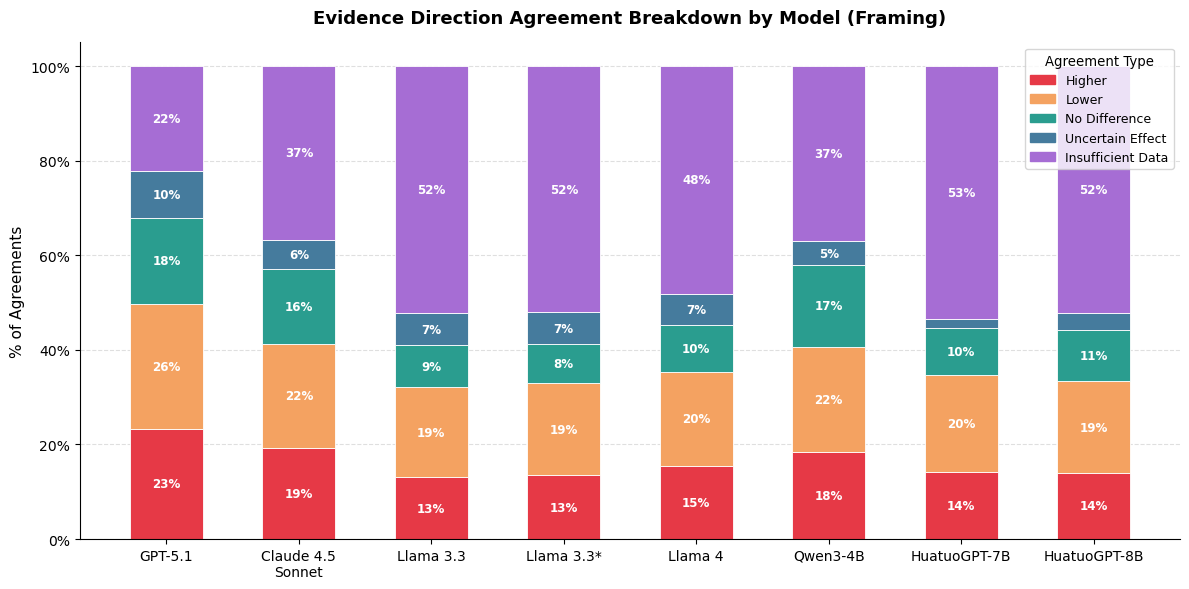

In [114]:
plot_agreement_breakdown(df_framing_agreements, title_suffix="Framing")